In [3]:
from pydantic import BaseModel
import re
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_mistralai import ChatMistralAI, MistralAIEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langchain_core.documents import Document
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
import requests
import asyncio

In [4]:
# llm = ChatMistralAI(model="mistral-large-latest")

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")

In [5]:
docs = (
    PyPDFLoader('thebook.pdf').load()
)

In [6]:


chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)


clean_chunks = [
    d for d in chunks
    if isinstance(d.page_content, str) and d.page_content.strip() != ""
]

In [7]:
embeddings = MistralAIEmbeddings(model="mistral-embed")
vector_store = FAISS.from_documents(clean_chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k":4})

/Users/sonu/projects/rag/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [9]:
class State(TypedDict):
    question: str
    docs: list[Document]
    good_docs: list[Document]
    verdict: str
    reason: str

    strips: list[str]
    kept_strips: list[str]
    refined_context: str
    web_query: str
    web_docs: list[Document]
    answer: str

In [10]:
async def retriever_node(state: State):
    q = state['question']
    docs = await retriever.ainvoke(q)
    return {"docs": docs}

In [11]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------

class DocEvalScore(BaseModel):
    score: float
    reason: str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)


doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)


async def eval_each_doc_node(state: State) -> State:
    q = state['question']
    docs = state["docs"]
    scores: list[float] = []
    good: list[Document] = []

    semaphore = asyncio.Semaphore(1)

    async def score_doc(d):
        async with semaphore:
            out = await doc_eval_chain.ainvoke({
                'question': q,
                'chunk': d.page_content
            })
            return out.score, d
    
    results = await asyncio.gather(*[score_doc(d) for d in docs])

    for score, d in results:
        scores.append(score)
        if score > LOWER_TH:
            good.append(d)



    # CORRECT at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }
    
    # INCORRECT all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }
    

    # AMBIGUOUS otherwise
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }


In [12]:
def decompose_to_sentences(text: str) -> list[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


class keepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(keepOrDrop)


# -----------------------------
# Knowledge refinement
# (CORRECT => internal only)
# (INCORRECT => web only)
# (AMBIGUOUS => internal + web)
# -----------------------------



async def refine(state: State) -> State:
    q = state['question']

    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_docs"]
    else:
        docs_to_use = state["good_docs"] + state["web_docs"]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    semaphore = asyncio.Semaphore(1)
    
    async def filter_sentence(s):
        async with semaphore:
            out = await filter_chain.ainvoke({
                "question": q,
                "sentence": s
            })
            return s if out.keep else None
    
    results = await asyncio.gather(*[filter_sentence(s) for s in strips])

    kept = [r for r in results if r]
    

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": "\n".join(kept).strip(),
    }


In [13]:
# Query rewrite for web search

class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)



rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)


async def rewrite_query_node(state: State) -> State:
    out = await rewrite_chain.ainvoke({"question": state["question"]})
    return {"web_query": out.query}



# Web search node

tavily = TavilySearchResults(max_results=5)

async def web_search_node(state: State) -> State:
    q = state["web_query"] or state["question"]
    
    results = await tavily.ainvoke({"query": q})

    web_docs: list[Document] = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}



/var/folders/dk/t18_r2s162b0jh344vvlgzc00000gn/T/ipykernel_14709/1791895738.py:34: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


In [14]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)


async def generate(state: State) -> str:
    out = await (answer_prompt | llm).ainvoke({"question": state["question"], "context": state["refined_context"]})
    return { "answer": out.content}

In [15]:
# -----------------------------
# Routing
# CORRECT => refine
# INCORRECT / AMBIGUOUS => rewrite -> web_search -> refine -> generate
# -----------------------------

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else: 
        return "rewrite_query"

In [16]:
# Build Graph

g = StateGraph(State)

g.add_node("retriever", retriever_node)
g.add_node("eval_each_doc_node", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retriever")
g.add_edge("retriever", "eval_each_doc_node")

g.add_conditional_edges(
    "eval_each_doc_node",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

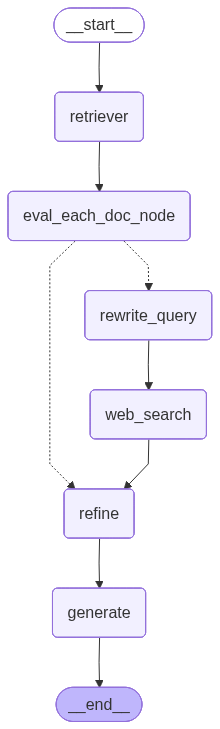

In [17]:
app

In [ ]:
# -----------------------------
# Run example
# -----------------------------
res = await app.ainvoke(
    {
        "question": "Smoothing Kernel",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_query": "",
        "web_docs": [],
        "answer": "",
    }
)

In [ ]:
res

{'question': 'What is Nearest Neighbor Estimators',
 'docs': [Document(id='aac03bca-e121-407e-8510-9dfabfb263c1', metadata={'producer': 'pdfTeX-1.40.10', 'creator': 'LaTeX with hyperref package', 'creationdate': '2010-10-01T15:47:05-07:00', 'author': 'AlexJ.SmolaandVishyS.V.N.Vishwanathan', 'title': 'AnIntroductiontoMachineLearning', 'subject': '', 'keywords': '', 'moddate': '2010-10-01T15:47:05-07:00', 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-1.40.10-2.2 (TeX Live/MacPorts 2009_6) kpathsea version 5.0.0', 'source': 'thebook.pdf', 'total_pages': 234, 'page': 31, 'page_label': '24'}, page_content='for j = 1 to n do\nt ← t + xj(log p0,j − log p1,j)\nend for\nif t > 0 return spam else return ham\n1.3.2 Nearest Neighbor Estimators\nAn even simpler estimator than Naive Bayes is nearest neighbors. In its most\nbasic form it assigns the label of its nearest neighbor to an observation x\n(see Figure 1.17). Hence, all we need to implement it is a distance measu